<a href="https://colab.research.google.com/github/joshuaeasojacob/LUXGEARS/blob/main/ASSIGNMENT_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [5]:
# Choose the  CSV file from your computer
from google.colab import files
uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Saving diabetes.csv to diabetes (1).csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# Univariate analysis
print(df["Outcome"].value_counts(normalize = True)*100)


Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


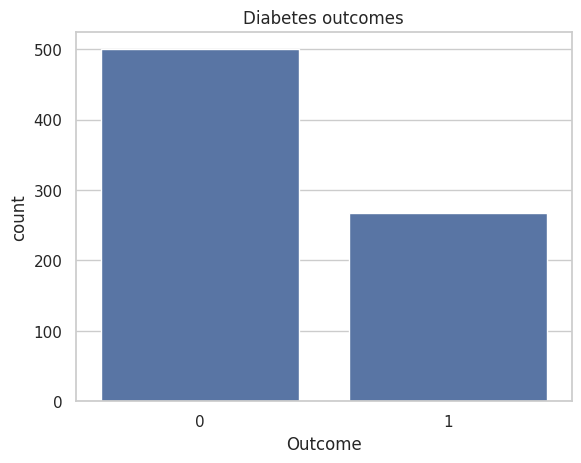

In [10]:
sns.countplot(data=df, x="Outcome")
plt.title("Diabetes outcomes")
plt.show()

The Outcome  is imbalanced. Approximately 65.1% of the observations have Outcome 0, while 34.9% have Outcome 1. This means the dataset contains more non-diabetic cases than diabetic cases.”

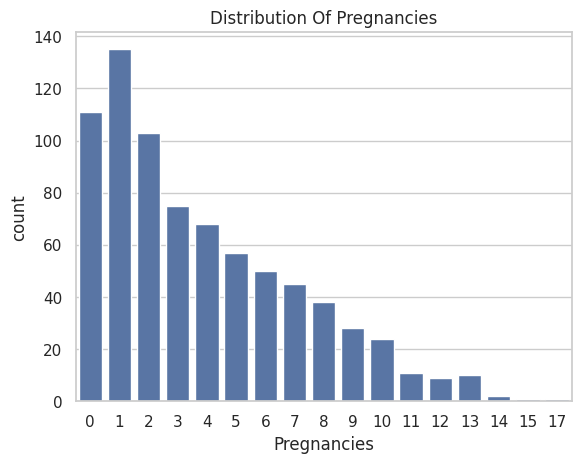

In [11]:
sns.countplot(data=df, x="Pregnancies",)
plt.title("Distribution Of Pregnancies")
plt.show()

Observation: This distribution shows that most women in the dataset had between 0 and 2 pregnancies. The frequency decreases as the number of pregnancies increases, with only a few having very high numbers of pregnancies.

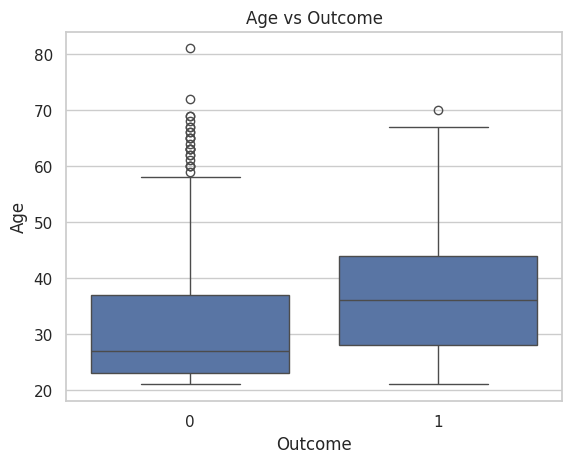

In [16]:
# Bivariate
sns.boxplot(data = df, x = "Outcome", y= "Age")
plt.title("Age vs Outcome")
plt.show()

Observation: this boxplot shows that the women with outcome 1 have moire age than others with outcome 0,the median age is also higher for the outcome 1 grp

In [13]:
numeric_df = df.select_dtypes(include = ["int64","float64"]).columns

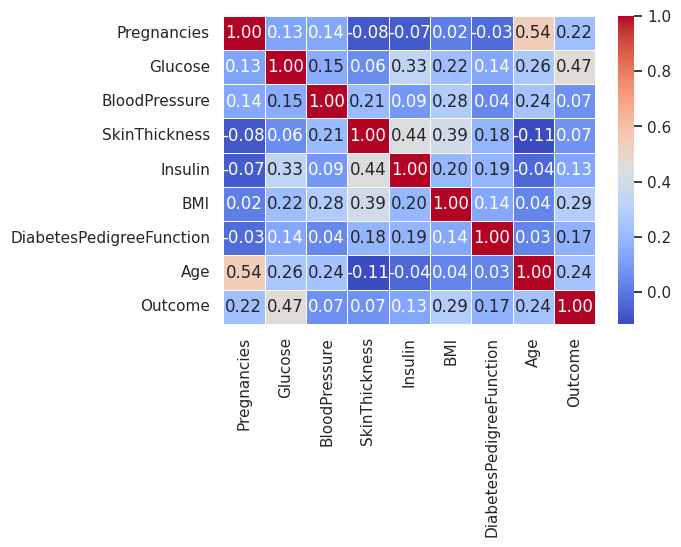

In [18]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap = "coolwarm",fmt= ".2f",linewidth = 0.5)
plt.show()

Observation: The correlation heatmap shows that Glucose has the strongest positive correlation with Outcome (0.47), followed by BMI (0.29), Age (0.24), and Pregnancies (0.22). The remaining variables show relatively low correlations with the diabetes outcome

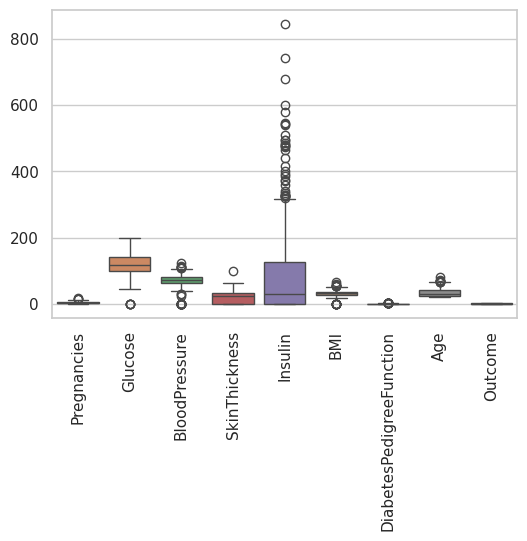

In [21]:
# Outlier detection
plt.figure(figsize=(6, 4))
sns.boxplot(data =df[numeric_df])
plt.xticks(rotation = 90)
plt.show()

In [23]:
# Detect Outliers using IQR
for col in numeric_df:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  count = ((df[col] < lower_bound) |
          (df[col] > upper_bound)).sum()

  print(col,":", count)

Pregnancies : 4
Glucose : 5
BloodPressure : 45
SkinThickness : 1
Insulin : 34
BMI : 19
DiabetesPedigreeFunction : 29
Age : 9
Outcome : 0


In [24]:
X=df.drop("Outcome",axis=1)
y=df["Outcome"]

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [27]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", random_state=42)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [33]:
y_pred = model.predict(X_test_scaled)


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6948051948051948
Precision: 0.5571428571428572
Recall   : 0.7090909090909091
F1 Score : 0.624


In [35]:
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[68 31]
 [16 39]]


observation: The confusion matrix shows 68 true negatives and 39 true positives, while 31 cases were false positives and 16 were false negatives. The model correctly classified 107 out of 154 test cases.

In [36]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.813406795224977


In [37]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

                    Feature  Coefficient
1                   Glucose     1.053811
5                       BMI     0.802195
7                       Age     0.482796
6  DiabetesPedigreeFunction     0.266917
0               Pregnancies     0.224270
3             SkinThickness     0.027661
4                   Insulin    -0.191189
2             BloodPressure    -0.244224
